In [116]:
import spacy
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE

In [117]:
nlp = spacy.load("en_core_web_lg")
df = pd.read_csv("../datasets/paraphrases_personas_14May.csv")

In [118]:
df["persona_key"] = ""
df.loc[df["persona"].str.startswith('John'), "persona_key"] = "Junior"
df.loc[df["persona"].str.startswith('Brad'), "persona_key"] = "Principal"
df.loc[df["persona"].str.startswith('Harold'), "persona_key"] = "Teacher"

In [119]:
embeddings = []
for text in df["paraphrase"]:
    doc = nlp(text)
    embedding = doc.vector
    embeddings.append(embedding)

embeddings = np.array(embeddings)
embeddings.shape

(330, 300)

In [120]:
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='random', learning_rate="auto")
vis_dims = tsne.fit_transform(embeddings)
vis_dims.shape

(330, 2)

In [121]:
df_with_2d_embeddings = df.copy(deep=True)
df_with_2d_embeddings['x'] = vis_dims[:,0]
df_with_2d_embeddings['y'] = vis_dims[:,1]

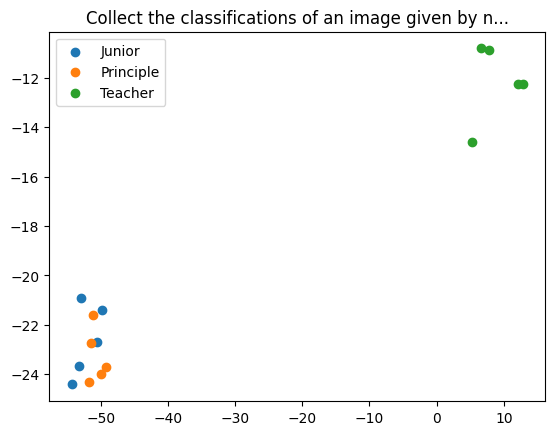

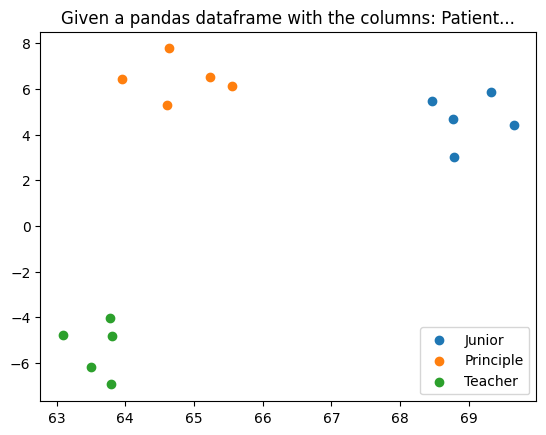

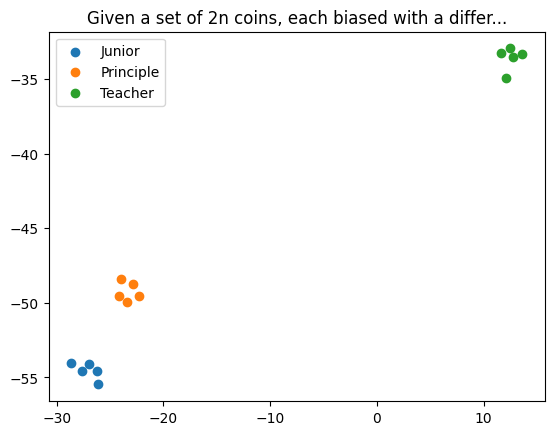

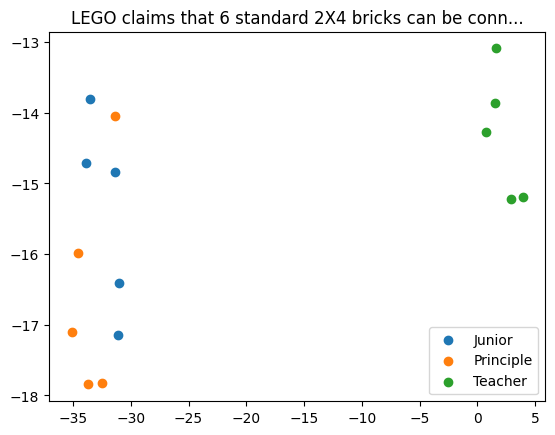

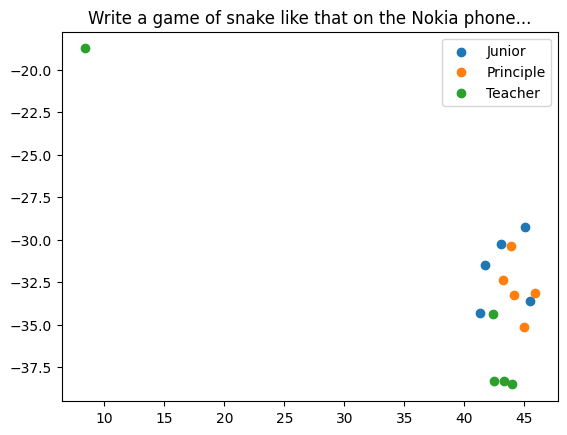

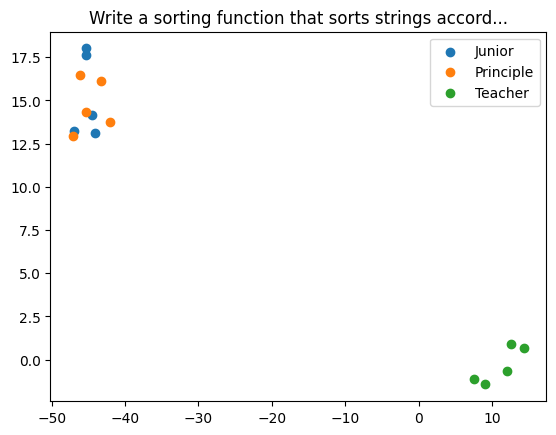

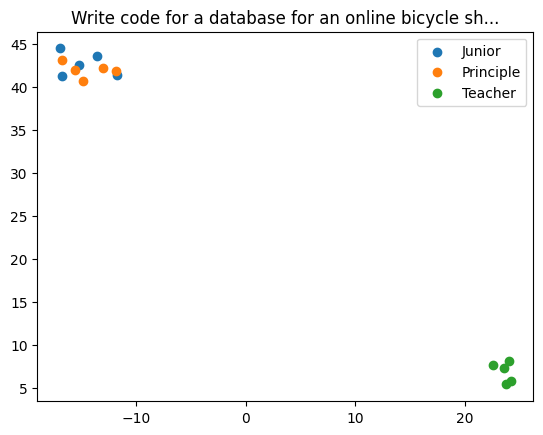

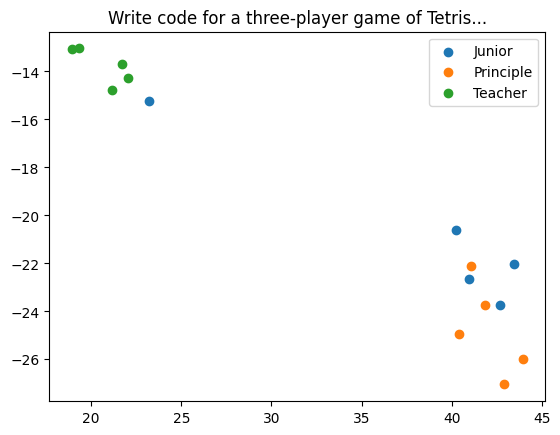

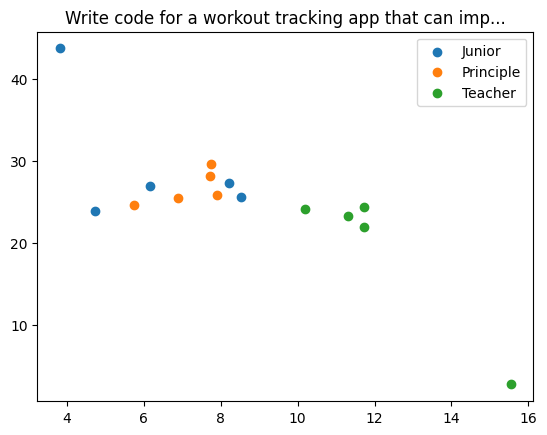

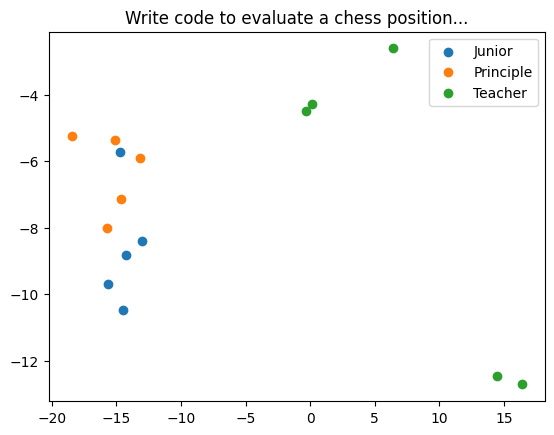

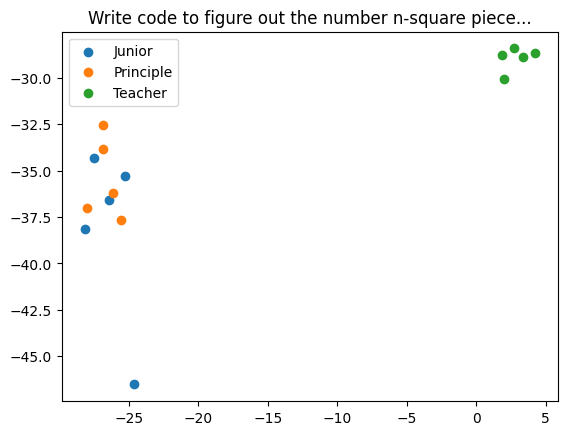

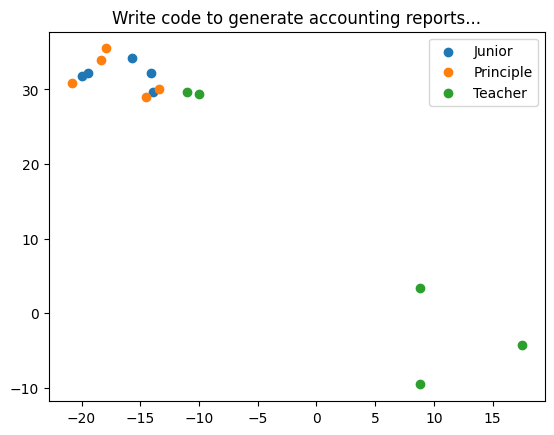

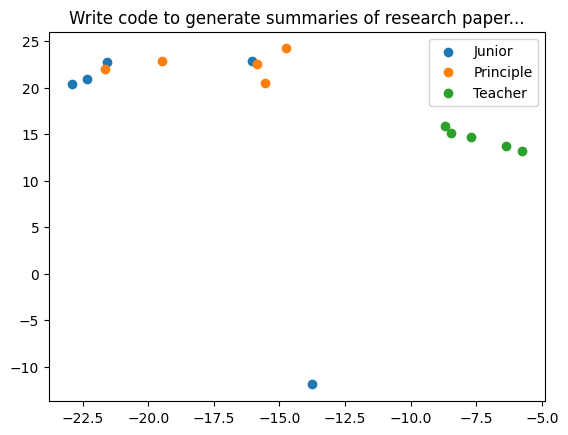

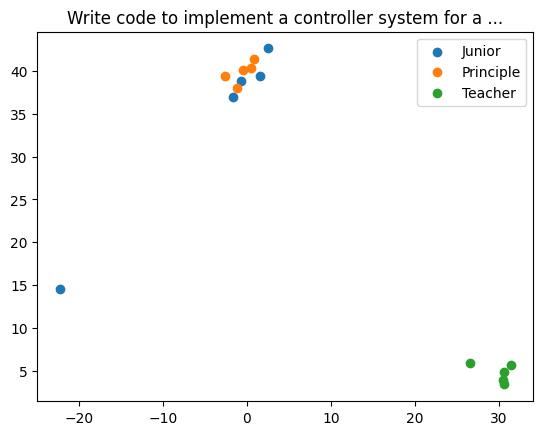

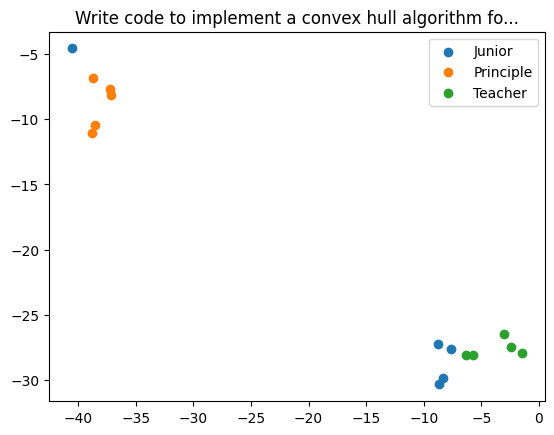

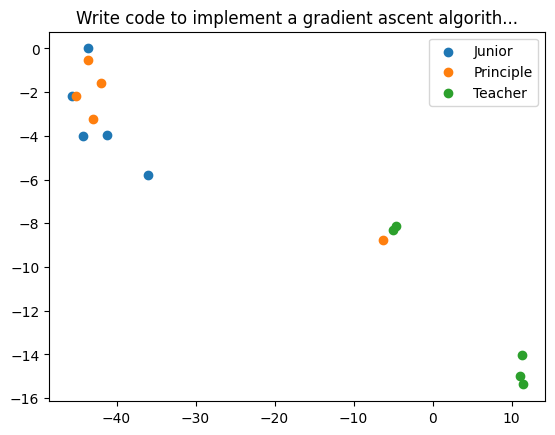

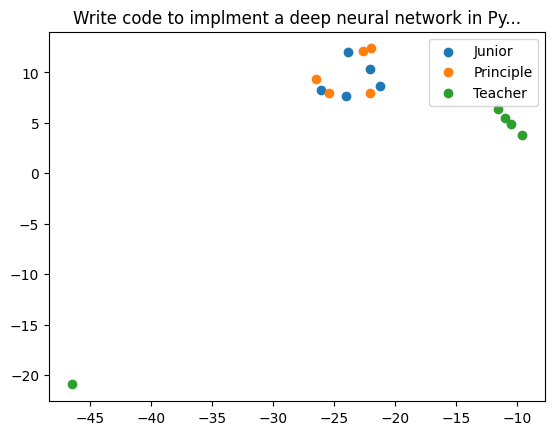

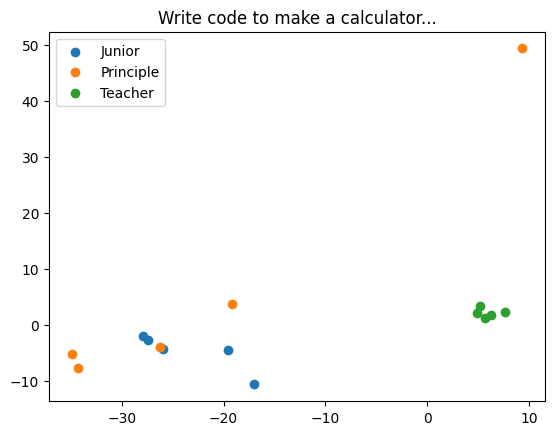

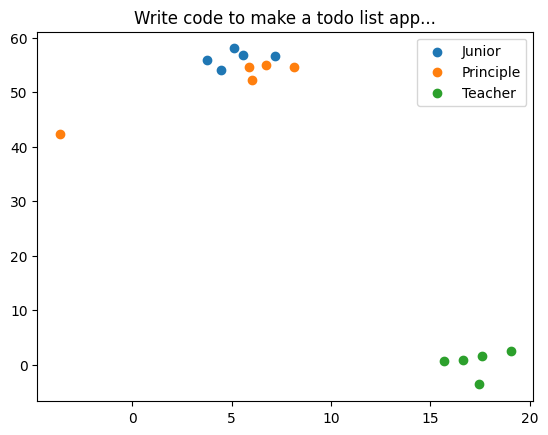

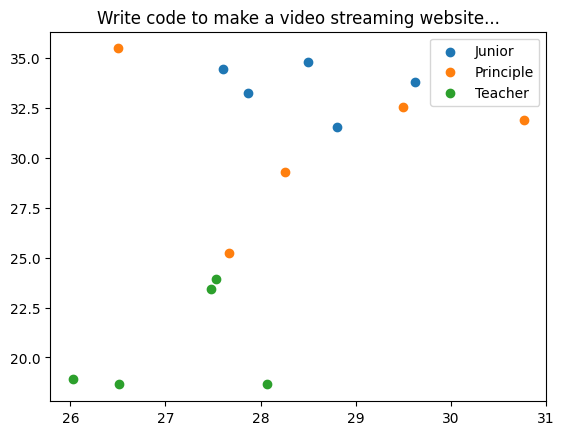

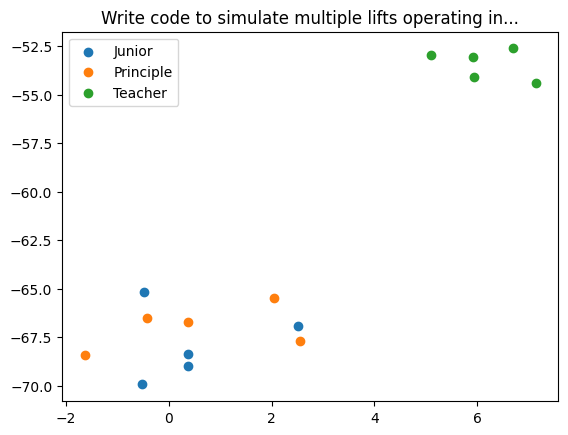

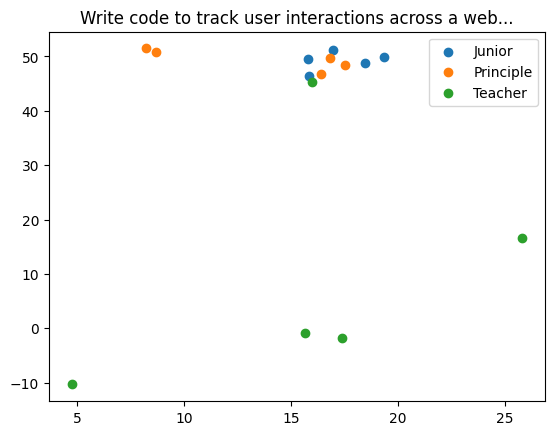

In [122]:
import matplotlib.pyplot as plt
import matplotlib

for group in df_with_2d_embeddings.groupby("original_phrase"):
    original_phrase = group[0]

    plt.scatter(group[1]['x'][:5], group[1]['y'][:5], label="Junior")
    plt.scatter(group[1]['x'][5:10], group[1]['y'][5:10], label="Principle")
    plt.scatter(group[1]['x'][10:15], group[1]['y'][10:15], label="Teacher")
    plt.title(original_phrase[:50] + "...")
    plt.legend()
    plt.show()